In [1]:
pip install torch torchvision stable-baselines3 gym numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gym
from gym import spaces
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
def get_data():
    transform = transforms.ToTensor()
    dataset = datasets.MNIST('.', train=True, download=True, transform=transform)

    dataset = Subset(dataset, list(range(2000)))

    client_data = []
    size = len(dataset) // 3 # number of clients

    for i in range(3):
        subset = Subset(dataset, list(range(i*size, (i+1)*size)))
        loader = DataLoader(subset, batch_size=32, shuffle=True)
        client_data.append(loader)

    return client_data

In [5]:
def train_client(model, loader, noise_std):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()

    for i, (x, y) in enumerate(loader):
        if i > 2:  # only 3 batches per round (because of performance reasons)
            break

        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()

        for p in model.parameters():
            if p.grad is not None:
                p.grad += torch.randn_like(p.grad) * noise_std

        optimizer.step()


In [6]:
def average_models(global_model, client_models):
    global_dict = global_model.state_dict()
    for key in global_dict:
        global_dict[key] = torch.stack(
            [m.state_dict()[key] for m in client_models], dim=0
        ).mean(0)
    global_model.load_state_dict(global_dict)

In [7]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    confidences = []

    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            probs = torch.softmax(out, dim=1)
            conf, pred = torch.max(probs, dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)
            confidences.extend(conf.cpu().numpy())

    acc = correct / total
    privacy = np.mean(confidences)
    return acc, privacy

In [8]:
class FederatedEnv(gym.Env):
    def __init__(self):
        super().__init__()

        self.clients = get_data()

        test_dataset = datasets.MNIST('.', train=False, download=True, transform=transforms.ToTensor())
        self.test_loader = DataLoader(Subset(test_dataset, list(range(500))), batch_size=128)

        self.global_model = SimpleCNN()
        self.noise = 0.5

        self.observation_space = spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Discrete(3)

        self.step_count = 0
        self.history = []

    def step(self, action):
        self.step_count += 1

        # adjust noise
        if action == 0:
            self.noise = max(0.0, self.noise - 0.1)
        elif action == 2:
            self.noise = min(2.0, self.noise + 0.1)

        # FL round
        client_models = []
        for loader in self.clients:
            local_model = SimpleCNN()
            local_model.load_state_dict(self.global_model.state_dict())
            train_client(local_model, loader, self.noise)
            client_models.append(local_model)

        average_models(self.global_model, client_models)

        acc, privacy = evaluate(self.global_model, self.test_loader)

        reward = acc - 0.5 * privacy 
        state = np.array([acc, self.noise], dtype=np.float32)
        print(f"[Step {self.step_count}] Noise={self.noise:.2f} Acc={acc:.3f} Privacy={privacy:.3f} Reward={reward:.3f}")

        self.history.append({
            "acc": acc,
            "privacy": privacy,
            "noise": self.noise,
            "reward": reward
        })

        terminated = self.step_count >= 20
        truncated = False

        return state, reward, terminated, truncated, {}

    def reset(self, seed=None, options=None):
        self.global_model = SimpleCNN()
        self.noise = 0.5
        self.step_count = 0
        self.history = []
        return np.array([0.0, self.noise], dtype=np.float32), {}

In [10]:
env = FederatedEnv()

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=200)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.35MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.74MB/s]


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[Step 1] Noise=0.40 Acc=0.084 Privacy=0.119 Reward=0.025
[Step 2] Noise=0.40 Acc=0.074 Privacy=0.118 Reward=0.015
[Step 3] Noise=0.50 Acc=0.078 Privacy=0.118 Reward=0.019
[Step 4] Noise=0.50 Acc=0.080 Privacy=0.118 Reward=0.021
[Step 5] Noise=0.40 Acc=0.100 Privacy=0.117 Reward=0.041
[Step 6] Noise=0.30 Acc=0.112 Privacy=0.118 Reward=0.053
[Step 7] Noise=0.40 Acc=0.124 Privacy=0.118 Reward=0.065
[Step 8] Noise=0.50 Acc=0.124 Privacy=0.118 Reward=0.065
[Step 9] Noise=0.50 Acc=0.130 Privacy=0.118 Reward=0.071
[Step 10] Noise=0.60 Acc=0.134 Privacy=0.118 Reward=0.075
[Step 11] Noise=0.50 Acc=0.150 Privacy=0.119 Reward=0.091
[Step 12] Noise=0.40 Acc=0.156 Privacy=0.118 Reward=0.097
[Step 13] Noise=0.30 Acc=0.164 Privacy=0.119 Reward=0.105
[Step 14] Noise=0.20 Acc=0.168 Privacy=0.119 Reward=0.108
[Step 15] Noise=0.20 Acc=0.174 Privacy=0.119 Reward=0.115
[Step 16] Noise=0.20 Acc=0.198 Privacy=0.118 Reward=0.139
[Step 17] Noise=0.20 Acc=0.208 Privacy=0.118 Reward=0.149
[Step 18] Noise=0.20 Ac

In [11]:
def run_rl(env, model):
    obs, _ = env.reset()
    done = False

    while not done:
        action, _ = model.predict(obs)
        obs, _, done, _, _ = env.step(action)

    return env.history

In [12]:
def run_fixed(env, noise_value=0.5):
    obs, _ = env.reset()
    done = False

    while not done:
        if noise_value < env.noise:
            action = 0
        elif noise_value > env.noise:
            action = 2
        else:
            action = 1

        obs, _, done, _, _ = env.step(action)

    return env.history


In [13]:
rl_data = run_rl(env, model)
fixed_data = run_fixed(env, 0.5)

[Step 1] Noise=0.40 Acc=0.170 Privacy=0.113 Reward=0.114
[Step 2] Noise=0.30 Acc=0.172 Privacy=0.112 Reward=0.116
[Step 3] Noise=0.20 Acc=0.192 Privacy=0.112 Reward=0.136
[Step 4] Noise=0.20 Acc=0.204 Privacy=0.113 Reward=0.148
[Step 5] Noise=0.20 Acc=0.202 Privacy=0.113 Reward=0.145
[Step 6] Noise=0.20 Acc=0.224 Privacy=0.113 Reward=0.168
[Step 7] Noise=0.30 Acc=0.234 Privacy=0.113 Reward=0.178
[Step 8] Noise=0.20 Acc=0.284 Privacy=0.113 Reward=0.228
[Step 9] Noise=0.10 Acc=0.306 Privacy=0.113 Reward=0.249
[Step 10] Noise=0.00 Acc=0.322 Privacy=0.113 Reward=0.265
[Step 11] Noise=0.10 Acc=0.346 Privacy=0.114 Reward=0.289
[Step 12] Noise=0.00 Acc=0.364 Privacy=0.114 Reward=0.307
[Step 13] Noise=0.00 Acc=0.380 Privacy=0.115 Reward=0.323
[Step 14] Noise=0.00 Acc=0.394 Privacy=0.115 Reward=0.336
[Step 15] Noise=0.10 Acc=0.398 Privacy=0.116 Reward=0.340
[Step 16] Noise=0.10 Acc=0.412 Privacy=0.116 Reward=0.354
[Step 17] Noise=0.00 Acc=0.418 Privacy=0.117 Reward=0.360
[Step 18] Noise=0.00 Ac

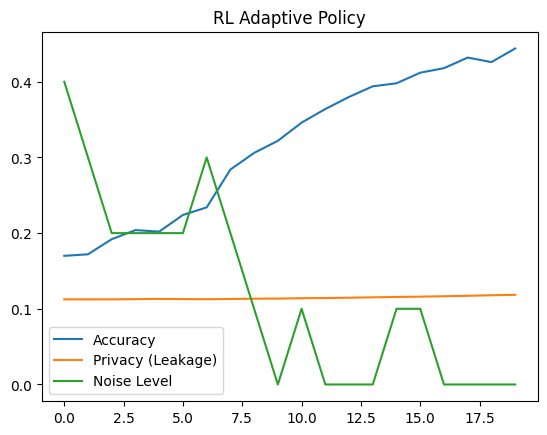

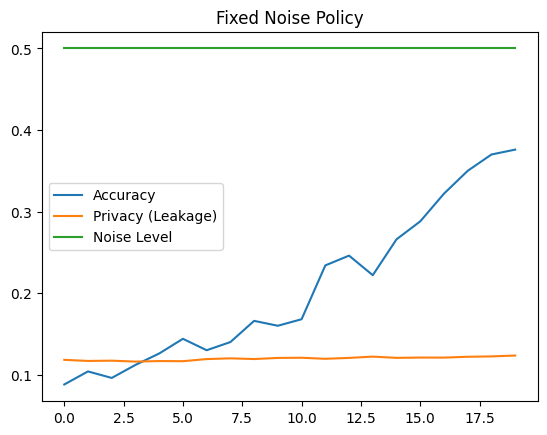

In [14]:
def plot_results(data, title):
    acc = [d["acc"] for d in data]
    privacy = [d["privacy"] for d in data]
    noise = [d["noise"] for d in data]

    plt.figure()
    plt.plot(acc, label="Accuracy")
    plt.plot(privacy, label="Privacy (Leakage)")
    plt.plot(noise, label="Noise Level")
    plt.title(title)
    plt.legend()
    plt.show()

plot_results(rl_data, "RL Adaptive Policy")
plot_results(fixed_data, "Fixed Noise Policy")

In [ ]:
obs, _ = env.reset()
for _ in range(5):
    action, _ = model.predict(obs)
    obs, _, done, _, _ = env.step(action)
    if done:
        break

[Step 1] Noise=0.40 Acc=0.108 Privacy=0.114 Reward=0.051
[Step 2] Noise=0.50 Acc=0.120 Privacy=0.115 Reward=0.062
[Step 3] Noise=0.40 Acc=0.136 Privacy=0.115 Reward=0.079
[Step 4] Noise=0.40 Acc=0.148 Privacy=0.116 Reward=0.090
[Step 5] Noise=0.40 Acc=0.176 Privacy=0.117 Reward=0.118
